# 02 — Análisis LLM de negociaciones — LockBit

Clasifica los 4,423 mensajes de negociación con `qwen2.5:14b` en fases  
del proceso de extorsión y perfila el estilo de cada operador.

**Diferencia clave con ContiLeaks/BlackBasta**: aquí los chats son entre  
_operadores LockBit_ (extorsionadores) y _víctimas_ (empresas comprometidas),  
no comunicación interna del grupo.

Produce:
- `data/processed/chats_classified.parquet`
- `data/processed/operator_profiles.json`

## 0. Setup

In [14]:
import json
import time
import pandas as pd
import numpy as np
import ollama
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm

PROCESSED        = Path('../data/processed')
CHATS_IN         = PROCESSED / 'chats.parquet'
USERS_IN         = PROCESSED / 'users.parquet'
CLIENTS_IN       = PROCESSED / 'clients.parquet'
CHATS_OUT        = PROCESSED / 'chats_classified.parquet'
PROFILES_OUT     = PROCESSED / 'operator_profiles.json'
CHECKPOINT_PATH  = PROCESSED / 'chats_checkpoint.parquet'

MODEL = 'qwen2.5:14b'

for f in [CHATS_IN, USERS_IN, CLIENTS_IN]:
    assert f.exists(), f'Falta {f} — ejecuta notebook 00'

chats   = pd.read_parquet(CHATS_IN)
users   = pd.read_parquet(USERS_IN)
clients = pd.read_parquet(CLIENTS_IN)

# Filtrar solo mensajes de texto (no archivos adjuntos)
chats_text = chats[chats.is_file == 0].copy()
chats_text = chats_text[chats_text.content.notna() & (chats_text.content.str.strip().str.len() > 3)]

print(f'Mensajes de texto: {len(chats_text):,}')
print(f'Adjuntos excluidos: {(chats.is_file==1).sum()}')
print('Setup OK')

Mensajes de texto: 3,977
Adjuntos excluidos: 188
Setup OK


## 1. Clasificación de fases de negociación

In [15]:
PHASES = {'opening', 'technical_proof', 'price_negotiation',
          'payment_instructions', 'closing', 'unknown'}

SYSTEM_PROMPT = """You are a threat intelligence analyst studying LockBit ransomware negotiation transcripts.
These are chats between LockBit operators (extortionists) and their victims (compromised companies).
Classify each message into exactly one phase of the extortion process:

- opening: first contact, welcome message, initial instructions for the victim
- technical_proof: requests for test files, proof of decryption, technical questions about encryption
- price_negotiation: ransom amount, discount requests, counter-offers, urgency pressure
- payment_instructions: bitcoin address, payment confirmation, wallet instructions
- closing: decryption key delivery, post-payment, farewell, threats if unpaid
- unknown: off-topic, unintelligible, empty, or cannot be classified

Reply with ONLY the phase name, nothing else."""

def classify_message(text: str, sender: str) -> str:
    if len(str(text).strip()) < 4:
        return 'unknown'
    try:
        resp = ollama.chat(
            model=MODEL,
            messages=[
                {'role': 'system', 'content': SYSTEM_PROMPT},
                {'role': 'user', 'content': f'Sender: {sender}\nMessage: {str(text)[:400]}'}
            ],
            options={'temperature': 0, 'num_predict': 10}
        )
        raw = resp.message.content.strip().lower().split()[0].rstrip('.,:;')
        return raw if raw in PHASES else 'unknown'
    except Exception:
        return 'unknown'

# Test rápido
print('Test de clasificación:')
tests = [
    ('You can attach a few files for test decryption', 'operator'),
    ('how much decrypt file', 'victim'),
    ('4000$\nwe accept bitcoin only', 'operator'),
    ('bc1qatkg42cxnv5vcxgz4wegkv2u6va9fztdkf6gwj', 'operator'),
]
for msg, sender in tests:
    phase = classify_message(msg, sender)
    print(f'  [{sender:8s}] "{msg[:50]}" → {phase}')

Test de clasificación:
  [operator] "You can attach a few files for test decryption" → technical_proof
  [victim  ] "how much decrypt file" → price_negotiation
  [operator] "4000$
we accept bitcoin only" → price_negotiation
  [operator] "bc1qatkg42cxnv5vcxgz4wegkv2u6va9fztdkf6gwj" → payment_instructions


In [16]:
# Cargar checkpoint si existe
if CHECKPOINT_PATH.exists():
    done = pd.read_parquet(CHECKPOINT_PATH)
    done_ids = set(done.index)
    print(f'Checkpoint: {len(done):,} mensajes ya clasificados')
else:
    done = pd.DataFrame()
    done_ids = set()
    print('Comenzando desde cero')

todo = chats_text[~chats_text.index.isin(done_ids)].copy()
print(f'Pendientes: {len(todo):,}')

Comenzando desde cero
Pendientes: 3,977


In [17]:
CHECKPOINT_EVERY = 50

results = []
t0 = time.time()

for i, (idx, row) in enumerate(tqdm(todo.iterrows(), total=len(todo), desc='Clasificando')):
    sender = 'operator' if row['flag'] == 1 else 'victim'
    phase = classify_message(row['content'], sender)
    results.append({'idx': idx, 'phase': phase})

    if (i + 1) % CHECKPOINT_EVERY == 0:
        chunk = pd.DataFrame(results).set_index('idx')
        partial = pd.concat([done,
                             chats_text.loc[chunk.index].assign(phase=chunk['phase'])])
        partial.to_parquet(CHECKPOINT_PATH)

elapsed = time.time() - t0
print(f'\nCompletado en {elapsed/60:.1f} min ({elapsed/max(len(todo),1):.1f} s/msg)')

new_df = pd.DataFrame(results).set_index('idx')
chats_new = chats_text.loc[new_df.index].copy()
chats_new['phase'] = new_df['phase'].values
classified = pd.concat([done, chats_new]).sort_values('created_at').reset_index(drop=True)
print(f'Total clasificados: {len(classified):,}')

Clasificando: 100%|██████████████████████████████████████████████████████████████████████| 3977/3977 [09:58<00:00,  6.64it/s]


Completado en 10.0 min (0.2 s/msg)
Total clasificados: 3,977


## 2. Análisis de resultados

In [18]:
phase_order = ['opening', 'technical_proof', 'price_negotiation',
               'payment_instructions', 'closing', 'unknown']
phase_colors = {
    'opening': '#3498db',
    'technical_proof': '#2ecc71',
    'price_negotiation': '#e74c3c',
    'payment_instructions': '#f39c12',
    'closing': '#9b59b6',
    'unknown': '#95a5a6'
}

print('=== DISTRIBUCIÓN GLOBAL DE FASES ===')
counts = classified['phase'].value_counts()
for p in phase_order:
    n = counts.get(p, 0)
    print(f'  {p:25s}: {n:4d}  ({n/len(classified)*100:.1f}%)')

=== DISTRIBUCIÓN GLOBAL DE FASES ===
  opening                  :  275  (6.9%)
  technical_proof          : 1122  (28.2%)
  price_negotiation        : 1154  (29.0%)
  payment_instructions     :  313  (7.9%)
  closing                  :  201  (5.1%)
  unknown                  :  912  (22.9%)


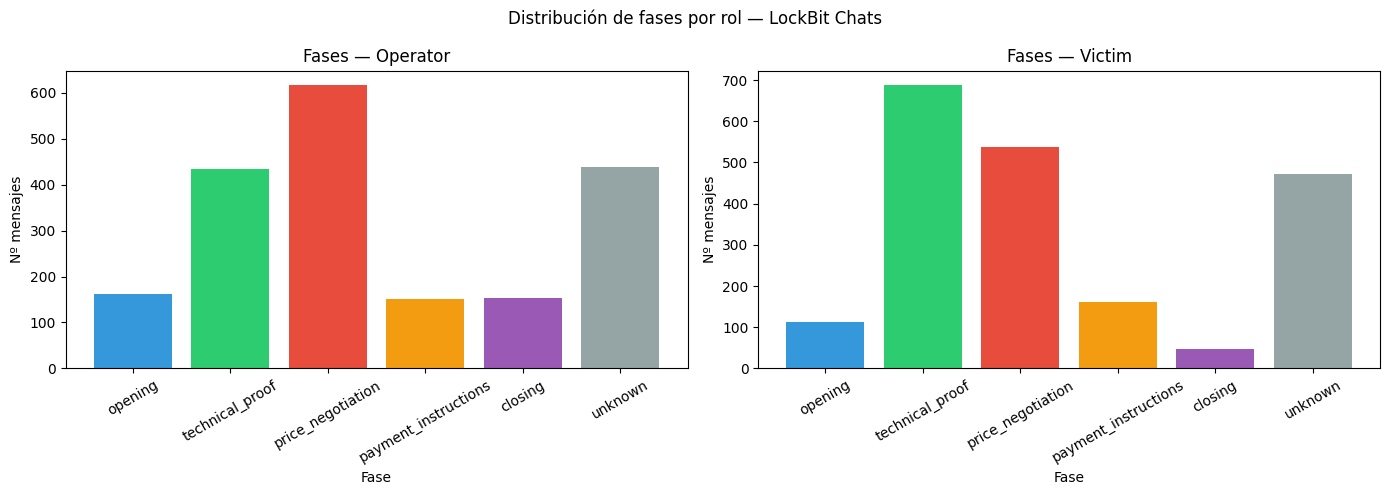

In [19]:
# Distribución por rol (operador vs víctima)
classified['sender'] = classified['flag'].map({1: 'operator', 0: 'victim'})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, sender in zip(axes, ['operator', 'victim']):
    sub = classified[classified.sender == sender]['phase'].value_counts()
    phases_present = [p for p in phase_order if p in sub.index]
    vals = [sub.get(p, 0) for p in phases_present]
    colors = [phase_colors[p] for p in phases_present]
    ax.bar(phases_present, vals, color=colors)
    ax.set_title(f'Fases — {sender.capitalize()}')
    ax.set_xlabel('Fase')
    ax.set_ylabel('Nº mensajes')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Distribución de fases por rol — LockBit Chats')
plt.tight_layout()
plt.show()

In [20]:
# Progresión temporal de fases en una negociación de ejemplo
# Tomamos la víctima con más mensajes
top_victim = classified.groupby('clientid').size().idxmax()
convo = classified[classified.clientid == top_victim].sort_values('created_at').reset_index(drop=True)

print(f'Negociación de ejemplo — víctima ID {top_victim} ({len(convo)} mensajes):')
for _, row in convo.iterrows():
    sender_label = '→ OPER' if row.flag == 1 else '← VÍCT'
    msg = str(row.content)[:80].replace('\n', ' ')
    dt = row.created_at.strftime('%d/%m %H:%M') if pd.notna(row.created_at) else '??/??'
    print(f"  [{dt}] {sender_label} [{row.phase:22s}] {msg}")

Negociación de ejemplo — víctima ID 182 (430 mensajes):
  [02/03 04:27] ← VÍCT [technical_proof       ] You can attach a few files for test decryption by packing them into an archive w
  [02/03 04:35] ← VÍCT [opening               ] I want to  recover my files, please help 
  [02/03 05:14] ← VÍCT [opening               ] 02.03.2025 04:27:34 UTC Loshara  I want to recover my files, please help 
  [02/03 06:39] → OPER [opening               ] Hello
  [02/03 06:40] ← VÍCT [opening               ] hello
  [02/03 06:41] → OPER [price_negotiation     ] price of decrypt will be 90k$ in bitcoin
  [02/03 06:41] → OPER [unknown               ] your company market
  [02/03 06:43] ← VÍCT [price_negotiation     ] please, give us us some kindly help, we are small business, not big company 
  [02/03 06:44] → OPER [technical_proof       ] and I saw your site which is not working now
  [02/03 06:45] ← VÍCT [price_negotiation     ] we are willing to solve the problem 
  [02/03 06:46] → OPER [technical_p

## 3. Métricas de negociación

In [21]:
# Duración de negociaciones (tiempo entre primer y último mensaje)
negotiation_stats = (classified.groupby('clientid').agg(
    n_msgs=('phase', 'count'),
    first_msg=('created_at', 'min'),
    last_msg=('created_at', 'max'),
    n_phases=('phase', 'nunique'),
).assign(duration_h=lambda df: (df.last_msg - df.first_msg).dt.total_seconds() / 3600)
.sort_values('n_msgs', ascending=False))

print('=== ESTADÍSTICAS DE NEGOCIACIONES ===')
print(f'Víctimas con chat activo : {len(negotiation_stats)}')
print(f'Msgs por negociación     : mediana={negotiation_stats.n_msgs.median():.0f}, máx={negotiation_stats.n_msgs.max()}')
print(f'Duración (horas)         : mediana={negotiation_stats.duration_h.median():.1f}, máx={negotiation_stats.duration_h.max():.0f}')
print(f'Fases distintas/negoc    : mediana={negotiation_stats.n_phases.median():.1f}')

# ¿Pagaron las víctimas con negociaciones más largas?
paid_ids = set(clients[clients.paid_commission == 1].id)
negotiation_stats['paid'] = negotiation_stats.index.isin(paid_ids)
print(f'\nVíctimas que pagaron con chat: {negotiation_stats.paid.sum()} de {len(negotiation_stats)}')
print('\nComparación pagadas vs no pagadas:')
print(negotiation_stats.groupby('paid')[['n_msgs','duration_h']].median().round(1).to_string())

=== ESTADÍSTICAS DE NEGOCIACIONES ===
Víctimas con chat activo : 208
Msgs por negociación     : mediana=4, máx=430
Duración (horas)         : mediana=8.2, máx=2962
Fases distintas/negoc    : mediana=2.0

Víctimas que pagaron con chat: 7 de 208

Comparación pagadas vs no pagadas:
       n_msgs  duration_h
paid                     
False     4.0         6.3
True    126.0       133.1


## 4. Perfilado de operadores

In [22]:
PROFILE_SYSTEM = """You are a threat intelligence analyst studying LockBit ransomware operators.
Given a sample of messages sent by one LockBit operator to victims, infer their negotiation style and role.

Reply in JSON with these fields:
{
  "style": "<one of: aggressive, professional, patient, scripted, technical>",
  "confidence": "<high|medium|low>",
  "summary": "<2-3 sentences in English describing their approach and typical behavior>",
  "tactics": ["<up to 3 observed negotiation tactics>"]
}"""

def profile_operator(op_id, messages: list[str]) -> dict:
    msg_block = '\n'.join(f'- {m[:200]}' for m in messages[:25])
    try:
        resp = ollama.chat(
            model=MODEL,
            messages=[
                {'role': 'system', 'content': PROFILE_SYSTEM},
                {'role': 'user', 'content': f'Operator ID: {op_id}\n\nMessages:\n{msg_block}'}
            ],
            options={'temperature': 0.1, 'num_predict': 300}
        )
        raw = resp.message.content.strip()
        start, end = raw.find('{'), raw.rfind('}') + 1
        return json.loads(raw[start:end])
    except Exception as e:
        return {'style': 'unknown', 'confidence': 'low', 'summary': str(e), 'tactics': []}

# Perfilar operadores con suficiente actividad
op_classified = classified[classified.flag == 1]  # solo mensajes del operador
active_ops = op_classified.groupby('advid').size()
active_ops = active_ops[active_ops >= 5].index.tolist()
print(f'Operadores a perfilar (≥5 mensajes): {len(active_ops)}')

Operadores a perfilar (≥5 mensajes): 20


In [23]:
operator_profiles = {}

for op_id in tqdm(active_ops, desc='Perfilando operadores'):
    msgs = op_classified[op_classified.advid == op_id]['content'].tolist()
    operator_profiles[int(op_id)] = profile_operator(op_id, msgs)

print('\n=== PERFILES DE OPERADORES ===')
for op_id, profile in operator_profiles.items():
    login = users[users.id == op_id]['login'].values
    login_str = login[0] if len(login) > 0 else f'ID_{op_id}'
    print(f'  {login_str:<20} [{profile.get("style","?"):12s}] ({profile.get("confidence","?")})')
    print(f'     {profile.get("summary","")[:100]}')

Perfilando operadores: 100%|█████████████████████████████████████████████████████████████████| 20/20 [00:46<00:00,  2.34s/it]


=== PERFILES DE OPERADORES ===
  Brown                [scripted    ] (high)
     The LockBit operator exhibits a scripted negotiation style, providing clear instructions and repeate
  PiotrBond            [aggressive  ] (medium)
     The LockBit operator demonstrates an aggressive negotiation style, repeatedly urging the victim to p
  ArrynBaird           [aggressive  ] (high)
     The LockBit operator with ID 13 employs an aggressive negotiation style, demanding immediate payment
  Anon666              [aggressive  ] (high)
     The LockBit operator exhibits an aggressive negotiation style, repeatedly demanding payment and thre
  GlenOrtega           [aggressive  ] (medium)
     The LockBit operator exhibits an aggressive negotiation style, setting a high ransom demand and refu
  jhon0722             [aggressive  ] (high)
     The LockBit operator exhibits an aggressive negotiation style, immediately pressing for higher ranso
  Christopher          [aggressive  ] (high)
     The Lock

## 5. Guardar resultados

In [24]:
classified.to_parquet(CHATS_OUT, index=False)

# Añadir login a perfiles antes de guardar
profiles_with_names = {}
for op_id, profile in operator_profiles.items():
    login = users[users.id == op_id]['login'].values
    name = login[0] if len(login) > 0 else f'ID_{op_id}'
    profiles_with_names[name] = profile

with open(PROFILES_OUT, 'w', encoding='utf-8') as f:
    json.dump(profiles_with_names, f, indent=2, ensure_ascii=False)

if CHECKPOINT_PATH.exists():
    CHECKPOINT_PATH.unlink()

print(f'Mensajes clasificados → {CHATS_OUT}')
print(f'Perfiles de operadores → {PROFILES_OUT}')
print(f'\nResumen: {len(classified):,} msgs | {len(operator_profiles)} operadores perfilados')

Mensajes clasificados → ../data/processed/chats_classified.parquet
Perfiles de operadores → ../data/processed/operator_profiles.json

Resumen: 3,977 msgs | 20 operadores perfilados
